# Student Marks Predictor + Weak Area Detector

This notebook is ready for Jupyter and includes step-by-step code with `# comments`.

It covers:
- dataset download
- preprocessing
- regression and classification
- feature importance
- weak area detection
- student-friendly prediction demo


## # Student Marks Predictor + Weak Area Detector

In [ ]:
# End-to-end project using the UCI Student Performance dataset
# This file is written in a Jupyter-friendly style with lots of comments
# so that students can understand what is happening in each step.

## # 1) OPTIONAL PACKAGE INSTALLATION

## # If you are running this in a fresh Jupyter environment,

In [ ]:
# uncomment the lines below and run them once.
#
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib requests

## # 2) IMPORT LIBRARIES

## # We import all the libraries needed for:

In [1]:
# - data loading
# - preprocessing
# - model building
# - evaluation
# - explanation / feature importance
# - saving trained models

import io
import os
import zipfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

## # 3) PROJECT PATHS

## # We create folders so that our notebook stays organized.

In [22]:
# - data/      -> raw dataset files
# - artifacts/ -> trained models and helper outputs

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

DATA_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder  :", DATA_DIR)
print("Artifacts    :", ARTIFACTS_DIR)

Project root: C:\Users\HP
Data folder  : C:\Users\HP\data
Artifacts    : C:\Users\HP\artifacts


## # 4) DOWNLOAD THE UCI STUDENT PERFORMANCE DATASET

## # The official old UCI ZIP file usually contains:

In [4]:
# - student-mat.csv
# - student-por.csv
# - student.txt (dataset description)
#
# Why do we need this step?
# Because we want the project to be fully end-to-end.
# So the notebook should be able to fetch the data for us.

def download_uci_student_performance_dataset(data_dir=DATA_DIR):
    # Official UCI location used by many student projects and tutorials
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
    zip_path = data_dir / "student.zip"

    # If the CSV files are already present, we skip the download
    mat_path = 'C:\\Users\\HP\\student-mat.csv'
    por_path = "C:\\Users\\HP\\student-por.csv"
    if mat_path.exists() and por_path.exists():
        print("Dataset already exists locally. Skipping download.")
        return mat_path, por_path

    print("Downloading dataset from official UCI source...")
    response = requests.get(url, timeout=60)
    response.raise_for_status()

    # Save the zip file
    with open(zip_path, "wb") as f:
        f.write(response.content)

    # Extract the zip file
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)

    print("Download complete.")
    print("Extracted files:", [p.name for p in data_dir.iterdir()])
    return mat_path, por_path

## # 5) LOAD BOTH SUBJECT DATASETS

## # The UCI dataset has two subject files:

In [24]:
# - Mathematics (student-mat.csv)
# - Portuguese (student-por.csv)
#
# We load both and add a new column called "subject"
# so that the final combined dataset knows which row came from which subject.

mat_path = 'C:\\Users\\HP\\student-mat.csv'
por_path = "C:\\Users\\HP\\student-por.csv"

df_mat = pd.read_csv(mat_path)
df_por = pd.read_csv(por_path)#, sep=";")

df_mat["subject"] = "math"
df_por["subject"] = "portuguese"

df = pd.concat([df_mat, df_por], ignore_index=True)

print("Math shape      :", df_mat.shape)
print("Portuguese shape:", df_por.shape)
print("Combined shape  :", df.shape)
print("\nColumns:\n", list(df.columns))

# Preview the first few rows
df.head()

Math shape      : (395, 34)
Portuguese shape: (649, 34)
Combined shape  : (1044, 34)

Columns:
 ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,MS,F,16,U,GT3,T,4,3,other,other,...,5,4,1,2,2,5,12,11,11,math
1,GP,M,18,U,GT3,T,3,2,services,health,...,2,3,1,4,5,11,13,15,16,math
2,GP,M,16,U,GT3,T,3,3,health,other,...,4,3,1,2,4,2,7,7,6,math
3,GP,F,16,R,GT3,T,4,4,at_home,teacher,...,1,3,1,3,3,1,13,12,12,math
4,MS,F,18,U,LE3,T,3,2,services,other,...,3,5,1,1,5,7,13,16,14,math


## # 6) BASIC DATA UNDERSTANDING

## # Before building any model, we should understand:

In [25]:
# - how many rows and columns we have
# - missing values
# - target distribution
# - whether the data types are numeric or categorical

print("Data types:\n")
print(df.dtypes)

print("\nMissing values per column:\n")
print(df.isna().sum().sort_values(ascending=False))

print("\nSummary statistics for numeric columns:\n")
display(df.describe())

Data types:

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
subject       object
dtype: object

Missing values per column:

school        0
goout         0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
Dalc          0
sex           0
Walc          0
health        0
absences      0
G1            0
G2    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.657088,2.845785,2.741379,1.653257,2.050766,0.364943,3.901341,3.271073,3.077586,1.541188,2.278736,3.853448,5.477969,11.272031,11.253831,11.068008
std,1.133148,1.082490,1.018606,0.873866,0.853794,0.769727,0.976639,1.026161,1.115873,0.899147,1.259247,1.180936,5.736503,3.750455,3.794043,3.994504
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,3.000000,3.000000,2.000000,1.000000,1.000000,3.000000,1.000000,9.000000,9.000000,9.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,17.000000,4.000000,4.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,14.000000,14.000000,14.000000
max,20.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,50.000000,20.000000,20.000000,20.000000


## # 7) TARGETS AND PROJECT-SPECIFIC FEATURE ENGINEERING

## # In the UCI dataset:

In [26]:
# - G1 = first period grade
# - G2 = second period grade
# - G3 = final grade
#
# The grade scale is 0 to 20.
#
# Since students often understand marks better on a 0 to 100 scale,
# we create a display version:
# - G3_100 = G3 * 5
#
# We also create:
# - pass_fail = 1 if G3 >= 10 else 0
# - attendance_proxy_pct from absences
#
# Important note:
# The original UCI dataset does NOT contain:
# - explicit attendance percentage
# - assignment submitted
# - sleep hours
#
# So for this project, attendance is approximated using absences.

df["G3_100"] = df["G3"] * 5
df["pass_fail"] = (df["G3"] >= 10).astype(int)

# Convert absences into a simple attendance proxy
# This is not the real attendance percentage from school records.
# It is just a classroom-friendly proxy:
# fewer absences -> better attendance proxy
max_absences = max(df["absences"].max(), 1)
df["attendance_proxy_pct"] = (1 - (df["absences"] / max_absences)) * 100
df["attendance_proxy_pct"] = df["attendance_proxy_pct"].clip(lower=0, upper=100)

display(df[["absences", "attendance_proxy_pct", "G1", "G2", "G3", "G3_100", "pass_fail"]].head())

,absences,attendance_proxy_pct,G1,G2,G3,G3_100,pass_fail
0,5,90.0,12,11,11,55,1
1,11,78.0,13,15,16,80,1
2,2,96.0,7,7,6,30,0
3,1,98.0,13,12,12,60,1
4,7,86.0,13,16,14,70,1


## # 8) SMALL EDA (EXPLORATORY DATA ANALYSIS)

## # We make a few simple plots so students can visually understand the data.

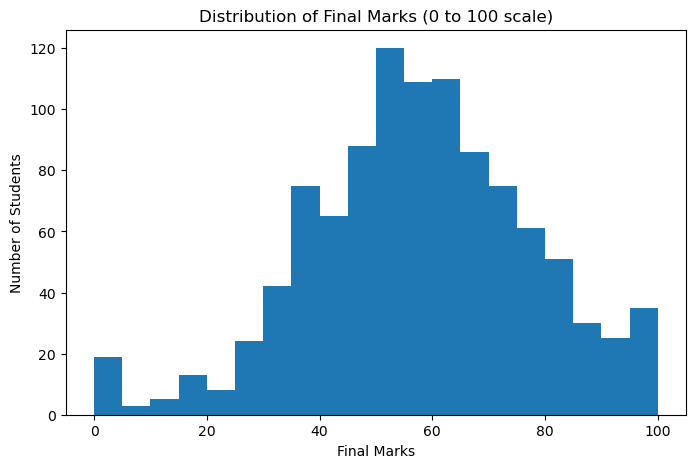

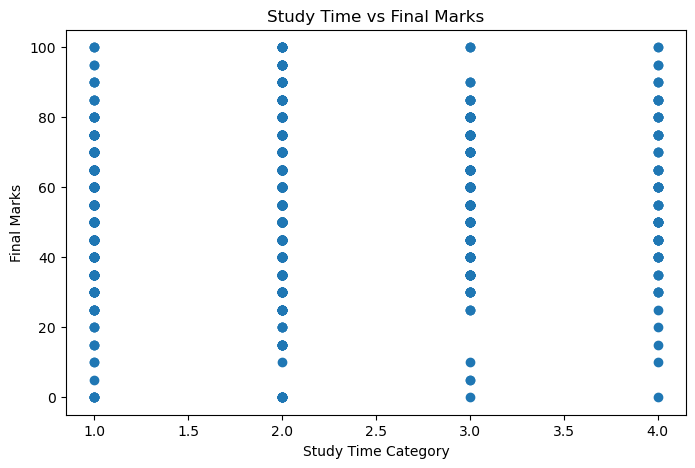

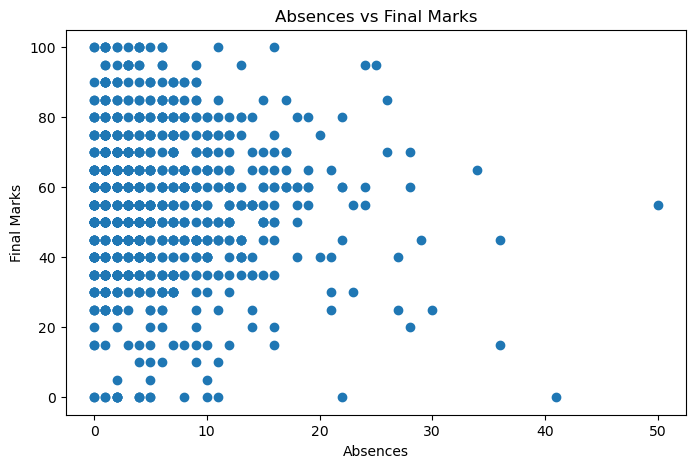

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(df["G3_100"], bins=20)
plt.title("Distribution of Final Marks (0 to 100 scale)")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["studytime"], df["G3_100"])
plt.title("Study Time vs Final Marks")
plt.xlabel("Study Time Category")
plt.ylabel("Final Marks")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["absences"], df["G3_100"])
plt.title("Absences vs Final Marks")
plt.xlabel("Absences")
plt.ylabel("Final Marks")
plt.show()

## # 9) SELECT FEATURES

## # We remove the direct targets from the input features.

In [28]:
# We keep G1 and G2 in the feature list because:
# - they are very strong predictors
# - they help demonstrate the idea of previous score affecting final score
#
# Later, if you want a stricter "early warning" version,
# you can exclude G1 and G2 as well.

target_regression = "G3"
target_classification = "pass_fail"

columns_to_drop_from_features = ["G3", "G3_100", "pass_fail"]
feature_df = df.drop(columns=columns_to_drop_from_features)

X = feature_df.copy()
y_reg = df[target_regression].copy()
y_clf = df[target_classification].copy()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)

Numeric features    : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'attendance_proxy_pct']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']


## # 10) TRAIN / TEST SPLIT

## # We split the data into train and test sets.

In [29]:
# The model learns on the train set and is evaluated on the test set.

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# For classification, we stratify so pass/fail proportions are preserved
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Regression train shape:", X_train.shape)
print("Regression test shape :", X_test.shape)
print("Classification train shape:", X_train_clf.shape)
print("Classification test shape :", X_test_clf.shape)

Regression train shape: (835, 34)
Regression test shape : (209, 34)
Classification train shape: (835, 34)
Classification test shape : (209, 34)


## # 11) PREPROCESSING PIPELINES

## # Why do we need preprocessing?

In [30]:
# - numeric missing values can be filled using the median
# - categorical missing values can be filled using the most frequent value
# - categorical text must be one-hot encoded
# - linear/logistic models usually benefit from scaling numeric features
#
# Tree-based models do not need scaling, so we create separate preprocessors.

numeric_linear_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_tree_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_linear_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_tree_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

## # 12) BUILD REGRESSION MODELS

## # Task: Predict final marks (G3 on 0-20 scale)

In [31]:
#
# Models used:
# - Linear Regression
# - Random Forest Regressor

linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression()),
    ]
)

random_forest_regressor_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            min_samples_leaf=2
        )),
    ]
)

regression_models = {
    "Linear Regression": linear_regression_model,
    "Random Forest Regressor": random_forest_regressor_model,
}

## # 13) TRAIN REGRESSION MODELS

## # We fit both models on the training data.

In [32]:
for name, model in regression_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_reg)

print("Regression model training complete.")

Training Linear Regression...
Training Random Forest Regressor...
Regression model training complete.


## # 14) EVALUATE REGRESSION MODELS

## # We compare:

In [33]:
# - MAE  (lower is better)
# - RMSE (lower is better)
# - R2   (higher is better)

regression_results = []

for name, model in regression_models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2 = r2_score(y_test_reg, preds)

    regression_results.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
    })

regression_results_df = pd.DataFrame(regression_results).sort_values(by="RMSE")
display(regression_results_df)

best_regression_model_name = regression_results_df.iloc[0]["Model"]
best_regression_model = regression_models[best_regression_model_name]

print("Best regression model:", best_regression_model_name)

,Model,MAE,RMSE,R2
0,Linear Regression,1.4459,2.1122,0.7516
1,Random Forest Regressor,1.4827,2.1636,0.7394


Best regression model: Linear Regression


## # 15) BUILD CLASSIFICATION MODELS

## # Task: Predict pass/fail

In [34]:
#
# Models used:
# - Logistic Regression
# - Decision Tree Classifier

logistic_regression_classifier = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

decision_tree_classifier = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=5,
            random_state=42,
            class_weight="balanced"
        )),
    ]
)

classification_models = {
    "Logistic Regression": logistic_regression_classifier,
    "Decision Tree Classifier": decision_tree_classifier,
}

## # 16) TRAIN CLASSIFICATION MODELS

## # We fit both classifiers.

In [35]:
for name, model in classification_models.items():
    print(f"Training {name}...")
    model.fit(X_train_clf, y_train_clf)

print("Classification model training complete.")

Training Logistic Regression...
Training Decision Tree Classifier...
Classification model training complete.


## # 17) EVALUATE CLASSIFICATION MODELS

## # We compare:

In [36]:
# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - ROC-AUC (when probability is available)

classification_results = []

for name, model in classification_models.items():
    preds = model.predict(X_test_clf)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_clf)[:, 1]
        roc_auc = roc_auc_score(y_test_clf, probs)
    else:
        roc_auc = np.nan

    classification_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test_clf, preds), 4),
        "Precision": round(precision_score(y_test_clf, preds, zero_division=0), 4),
        "Recall": round(recall_score(y_test_clf, preds, zero_division=0), 4),
        "F1": round(f1_score(y_test_clf, preds, zero_division=0), 4),
        "ROC_AUC": round(roc_auc, 4) if not np.isnan(roc_auc) else np.nan,
    })

classification_results_df = pd.DataFrame(classification_results).sort_values(by="F1", ascending=False)
display(classification_results_df)

best_classification_model_name = classification_results_df.iloc[0]["Model"]
best_classification_model = classification_models[best_classification_model_name]

print("Best classification model:", best_classification_model_name)

# Also print a detailed report for the best classifier
best_clf_preds = best_classification_model.predict(X_test_clf)
print("\nDetailed classification report:\n")
print(classification_report(y_test_clf, best_clf_preds, zero_division=0))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8134,0.9180,0.7943,0.8517,0.8912
1,Decision Tree Classifier,0.7560,0.9167,0.7021,0.7952,0.8084


Best classification model: Logistic Regression

Detailed classification report:

              precision    recall  f1-score   support

           0       0.67      0.85      0.75        68
           1       0.92      0.79      0.85       141

    accuracy                           0.81       209
   macro avg       0.79      0.82      0.80       209
weighted avg       0.84      0.81      0.82       209



## # 18) PERMUTATION IMPORTANCE FOR EXPLANATION

## # We use permutation importance because:

,feature,importance_mean,importance_std
31,G2,1.777288,0.079343
30,G1,0.663180,0.041177
14,failures,0.167497,0.012129
28,health,0.012248,0.006910
13,studytime,0.010012,0.003536
32,subject,0.005512,0.005935
25,goout,0.003194,0.003809
1,sex,0.002614,0.000965
24,freetime,0.002106,0.002129
17,paid,0.001938,0.001866


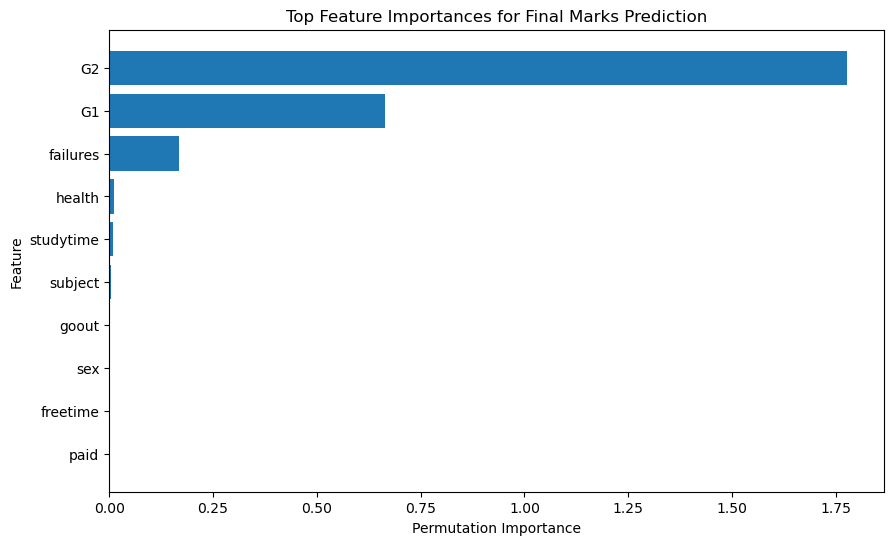

In [37]:
# - it is model agnostic
# - it works well for student-friendly explanation
# - it directly tells us which original input columns matter most
#
# For the regression model, we use negative RMSE as the scoring direction.
# Higher positive importance = more important feature.

reg_perm = permutation_importance(
    best_regression_model,
    X_test,
    y_test_reg,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
)

reg_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": reg_perm.importances_mean,
    "importance_std": reg_perm.importances_std,
}).sort_values(by="importance_mean", ascending=False)

display(reg_importance_df.head(15))

plt.figure(figsize=(10, 6))
top_reg_imp = reg_importance_df.head(10).sort_values(by="importance_mean")
plt.barh(top_reg_imp["feature"], top_reg_imp["importance_mean"])
plt.title("Top Feature Importances for Final Marks Prediction")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

## # 19) SAVE TRAINED MODELS

## # Saving the trained models lets us reuse them later without retraining.

In [38]:
joblib.dump(best_regression_model, ARTIFACTS_DIR / "best_regression_model.joblib")
joblib.dump(best_classification_model, ARTIFACTS_DIR / "best_classification_model.joblib")
joblib.dump(reg_importance_df, ARTIFACTS_DIR / "regression_feature_importance.joblib")

print("Saved model artifacts to:", ARTIFACTS_DIR)

Saved model artifacts to: C:\Users\HP\artifacts


## # 20) CREATE DEFAULT VALUES FOR NEW STUDENT INPUT

## # When we predict for a brand-new student, we may not want to manually

In [39]:
# fill every single field. So we create a default template using:
# - median for numeric columns
# - mode for categorical columns

def build_default_student_template(reference_df):
    template = {}
    for col in reference_df.columns:
        if pd.api.types.is_numeric_dtype(reference_df[col]):
            template[col] = float(reference_df[col].median())
        else:
            template[col] = reference_df[col].mode().iloc[0]
    return template

default_student_template = build_default_student_template(X)
default_student_template

{'school': 'GP',
 'sex': 'F',
 'age': 17.0,
 'address': 'U',
 'famsize': 'GT3',
 'Pstatus': 'T',
 'Medu': 3.0,
 'Fedu': 3.0,
 'Mjob': 'other',
 'Fjob': 'other',
 'reason': 'course',
 'guardian': 'mother',
 'traveltime': 1.0,
 'studytime': 2.0,
 'failures': 0.0,
 'schoolsup': 'no',
 'famsup': 'yes',
 'paid': 'no',
 'activities': 'yes',
 'nursery': 'yes',
 'higher': 'yes',
 'internet': 'yes',
 'romantic': 'no',
 'famrel': 4.0,
 'freetime': 3.0,
 'goout': 3.0,
 'Dalc': 1.0,
 'Walc': 2.0,
 'health': 4.0,
 'absences': 4.0,
 'G1': 11.0,
 'G2': 11.0,
 'subject': 'portuguese',
 'attendance_proxy_pct': 92.0}

## # 21) STUDENT-FRIENDLY INPUT MAPPER

## # The user idea is:

In [40]:
# - study hours per day
# - attendance %
# - previous test score
# - assignment submitted
# - sleep hours
# - internet usage
#
# But the UCI dataset does not have all of those exact columns.
#
# So this function converts simple student-friendly inputs into the
# nearest UCI-like features so we can still build a nice demo.

def map_study_hours_per_day_to_uci_studytime(hours_per_day):
    # UCI studytime categories are approximately weekly study time:
    # 1 = <2 hours/week
    # 2 = 2 to 5 hours/week
    # 3 = 5 to 10 hours/week
    # 4 = >10 hours/week
    weekly_hours = hours_per_day * 7

    if weekly_hours < 2:
        return 1
    elif weekly_hours <= 5:
        return 2
    elif weekly_hours <= 10:
        return 3
    else:
        return 4

def map_attendance_pct_to_absences(attendance_pct, max_reasonable_absences=30):
    # This is only a rough demo mapping for student-facing input.
    # Higher attendance % -> fewer absences
    attendance_pct = float(np.clip(attendance_pct, 0, 100))
    absences = round((100 - attendance_pct) / 100 * max_reasonable_absences)
    return int(absences)

def map_previous_test_score_100_to_grade_20(score_100):
    score_100 = float(np.clip(score_100, 0, 100))
    return int(round(score_100 / 5))

def map_internet_usage_to_uci_internet(internet_usage):
    # UCI has only yes/no internet access, not low/medium/high usage
    internet_usage = str(internet_usage).strip().lower()
    if internet_usage in {"none", "no", "not available"}:
        return "no"
    return "yes"

def build_student_row_from_simple_inputs(
    study_hours_per_day=4,
    attendance_pct=82,
    previous_test_score=65,
    assignment_submitted="Yes",
    sleep_hours=6,
    internet_usage="Medium",
    subject="math",
):
    # Start with a sensible template from historical data
    row = default_student_template.copy()

    # Fill the fields that we can map honestly to the UCI data
    row["subject"] = "math" if str(subject).lower().startswith("math") else "portuguese"
    row["studytime"] = map_study_hours_per_day_to_uci_studytime(study_hours_per_day)
    row["absences"] = map_attendance_pct_to_absences(attendance_pct)
    row["G1"] = map_previous_test_score_100_to_grade_20(previous_test_score)
    row["G2"] = map_previous_test_score_100_to_grade_20(previous_test_score)
    row["internet"] = map_internet_usage_to_uci_internet(internet_usage)

    # Keep a note for the user:
    # assignment_submitted and sleep_hours are NOT real UCI features.
    # We accept them at the interface level for demo friendliness,
    # but they are not used by the baseline UCI model.
    row["_input_assignment_submitted"] = assignment_submitted
    row["_input_sleep_hours"] = sleep_hours
    row["_input_attendance_pct"] = attendance_pct
    row["_input_study_hours_per_day"] = study_hours_per_day
    row["_input_previous_test_score_100"] = previous_test_score
    row["_input_internet_usage"] = internet_usage

    return pd.DataFrame([row])

simple_demo_student = build_student_row_from_simple_inputs()
display(simple_demo_student)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G1,G2,subject,attendance_proxy_pct,_input_assignment_submitted,_input_sleep_hours,_input_attendance_pct,_input_study_hours_per_day,_input_previous_test_score_100,_input_internet_usage
0,GP,F,17.0,U,GT3,T,3.0,3.0,other,other,...,13,13,math,92.0,Yes,6,82,4,65,Medium


## # 22) WEAK AREA DETECTOR

## # This is the project's novel touch.

In [41]:
#
# We do not only predict marks.
# We also produce:
# - risk level
# - top reasons for lower score
# - short improvement recommendations
#
# We use:
# 1) feature importance from the best regression model
# 2) simple domain rules for actionable features
#
# We intentionally avoid using sensitive / non-actionable features
# like sex or parents' job as "reasons" in the student feedback panel.

actionable_features = {
    "attendance_proxy_pct": "Low attendance / too many absences",
    "absences": "High number of absences",
    "studytime": "Low study time",
    "G1": "Low previous test score (G1)",
    "G2": "Low previous test score (G2)",
    "failures": "Past academic failures",
    "traveltime": "Long travel time",
    "internet": "No home internet access",
    "higher": "Low higher-education aspiration",
    "paid": "No extra paid classes / support",
}

importance_lookup = dict(
    zip(
        reg_importance_df["feature"],
        np.maximum(reg_importance_df["importance_mean"], 0)
    )
)

def compute_attendance_proxy_from_absences(absences, max_reference=max_absences):
    value = (1 - (absences / max_reference)) * 100
    return float(np.clip(value, 0, 100))

def get_risk_level(predicted_marks_100):
    # You can change these thresholds if your school prefers different bands.
    if predicted_marks_100 < 50:
        return "High"
    elif predicted_marks_100 < 70:
        return "Medium"
    return "Low"

def feature_weakness_score(feature_name, value):
    # Converts a raw value into a weakness score between 0 and 1.
    # Higher means more concerning.
    if feature_name == "attendance_proxy_pct":
        if value >= 85:
            return 0.0
        elif value >= 75:
            return 0.4
        elif value >= 60:
            return 0.7
        return 1.0

    if feature_name == "absences":
        if value <= 2:
            return 0.0
        elif value <= 5:
            return 0.3
        elif value <= 10:
            return 0.7
        return 1.0

    if feature_name == "studytime":
        # In UCI, lower studytime category means less study
        if value >= 4:
            return 0.0
        elif value == 3:
            return 0.2
        elif value == 2:
            return 0.6
        return 1.0

    if feature_name in {"G1", "G2"}:
        # Since these are out of 20
        if value >= 15:
            return 0.0
        elif value >= 12:
            return 0.3
        elif value >= 10:
            return 0.6
        return 1.0

    if feature_name == "failures":
        if value == 0:
            return 0.0
        elif value == 1:
            return 0.5
        return 1.0

    if feature_name == "traveltime":
        if value <= 1:
            return 0.0
        elif value == 2:
            return 0.3
        elif value == 3:
            return 0.6
        return 1.0

    if feature_name == "internet":
        return 1.0 if str(value).lower() == "no" else 0.0

    if feature_name == "higher":
        return 1.0 if str(value).lower() == "no" else 0.0

    if feature_name == "paid":
        return 0.4 if str(value).lower() == "no" else 0.0

    return 0.0

def get_top_reasons_for_low_score(student_row_df, top_n=3):
    # student_row_df must contain one row
    student_row = student_row_df.iloc[0].to_dict()

    # Ensure attendance proxy is available
    if "attendance_proxy_pct" not in student_row:
        student_row["attendance_proxy_pct"] = compute_attendance_proxy_from_absences(
            student_row.get("absences", 0)
        )

    scored_reasons = []

    for feature, readable_reason in actionable_features.items():
        if feature in student_row:
            weakness = feature_weakness_score(feature, student_row[feature])
            importance = importance_lookup.get(feature, 0.01)
            score = weakness * importance
            scored_reasons.append((readable_reason, feature, score, student_row[feature]))

    # Sort by severity score, highest first
    scored_reasons = sorted(scored_reasons, key=lambda x: x[2], reverse=True)

    # Keep only meaningful reasons
    meaningful = [item for item in scored_reasons if item[2] > 0]

    # If nothing is strongly weak, return a gentle message
    if not meaningful:
        return ["No major weak area detected from the available UCI features."]

    return [item[0] for item in meaningful[:top_n]]

def generate_recommendations_from_reasons(reasons):
    recommendation_map = {
        "Low attendance / too many absences": "Try to improve class attendance and reduce missed lectures.",
        "High number of absences": "Track missed classes weekly and revise the topics covered in those classes.",
        "Low study time": "Create a fixed daily study schedule and increase focused study time gradually.",
        "Low previous test score (G1)": "Revise the first-term weak topics and practice more solved examples.",
        "Low previous test score (G2)": "Work on second-term revision and identify where mistakes are repeating.",
        "Past academic failures": "Spend extra time on foundational concepts before moving to advanced topics.",
        "Long travel time": "Use commute time for light revision, flashcards, or audio learning.",
        "No home internet access": "Download notes in advance or use offline learning materials when possible.",
        "Low higher-education aspiration": "Set a clear academic goal because goals often improve consistency.",
        "No extra paid classes / support": "Consider mentorship, peer study groups, or low-cost learning support.",
    }

    recommendations = []
    for reason in reasons:
        if reason in recommendation_map:
            recommendations.append(recommendation_map[reason])
    return recommendations

## # 23) FINAL PREDICTION FUNCTION

## # This function gives a complete student-facing output:

In [42]:
# - predicted final marks (0-20 and 0-100)
# - pass probability
# - risk level
# - weak areas
# - recommendations

def predict_student_outcome(student_input_df):
    # Keep only the columns that the model was trained on
    model_input = student_input_df[X.columns].copy()

    # Add attendance proxy if missing so weak area logic can use it
    helper_df = model_input.copy()
    helper_df["attendance_proxy_pct"] = helper_df["absences"].apply(compute_attendance_proxy_from_absences)

    # Predict final marks using the best regression model
    predicted_g3 = float(best_regression_model.predict(model_input)[0])

    # Predict pass/fail and pass probability using the best classifier
    predicted_pass = int(best_classification_model.predict(model_input)[0])

    if hasattr(best_classification_model, "predict_proba"):
        pass_probability = float(best_classification_model.predict_proba(model_input)[0, 1])
    else:
        pass_probability = float(predicted_pass)

    predicted_marks_100 = np.clip(predicted_g3 * 5, 0, 100)
    risk_level = get_risk_level(predicted_marks_100)

    weak_reasons = get_top_reasons_for_low_score(helper_df, top_n=3)
    recommendations = generate_recommendations_from_reasons(weak_reasons)

    result = {
        "predicted_final_marks_out_of_20": round(predicted_g3, 2),
        "predicted_final_marks_out_of_100": round(predicted_marks_100, 2),
        "predicted_pass_flag": predicted_pass,
        "pass_probability": round(pass_probability, 4),
        "risk_level": risk_level,
        "top_reasons_for_low_score": weak_reasons,
        "recommendations": recommendations,
    }
    return result

## # 24) DEMO PREDICTION USING THE STUDENT-FRIENDLY INTERFACE

## # This demo tries to match your original idea:

In [43]:
# - study hours per day = 4
# - attendance = 82%
# - previous test score = 65
# - assignment submitted = Yes
# - sleep hours = 6
# - internet usage = Medium

demo_student = build_student_row_from_simple_inputs(
    study_hours_per_day=4,
    attendance_pct=82,
    previous_test_score=65,
    assignment_submitted="Yes",
    sleep_hours=6,
    internet_usage="Medium",
    subject="math",
)

demo_result = predict_student_outcome(demo_student)

print("Demo student result:\n")
for key, value in demo_result.items():
    print(f"{key}: {value}")

Demo student result:

predicted_final_marks_out_of_20: 13.09
predicted_final_marks_out_of_100: 65.46
predicted_pass_flag: 1
pass_probability: 0.9419
risk_level: Medium
top_reasons_for_low_score: ['Low previous test score (G2)', 'Low previous test score (G1)', 'No extra paid classes / support']
recommendations: ['Work on second-term revision and identify where mistakes are repeating.', 'Revise the first-term weak topics and practice more solved examples.', 'Consider mentorship, peer study groups, or low-cost learning support.']


## # 25) SHOW THE RESULT IN A CLEANER WAY

## # This makes the classroom demo look nicer.

In [44]:
print("\n" + "=" * 60)
print("STUDENT MARKS PREDICTOR + WEAK AREA DETECTOR")
print("=" * 60)
print(f"Predicted final marks : {demo_result['predicted_final_marks_out_of_100']} / 100")
print(f"Risk level            : {demo_result['risk_level']}")
print(f"Pass probability      : {demo_result['pass_probability']}")
print("\nTop reasons for lower score:")
for i, reason in enumerate(demo_result["top_reasons_for_low_score"], start=1):
    print(f"{i}. {reason}")

print("\nRecommendations:")
for i, rec in enumerate(demo_result["recommendations"], start=1):
    print(f"{i}. {rec}")


STUDENT MARKS PREDICTOR + WEAK AREA DETECTOR
Predicted final marks : 65.46 / 100
Risk level            : Medium
Pass probability      : 0.9419

Top reasons for lower score:
1. Low previous test score (G2)
2. Low previous test score (G1)
3. No extra paid classes / support

Recommendations:
1. Work on second-term revision and identify where mistakes are repeating.
2. Revise the first-term weak topics and practice more solved examples.
3. Consider mentorship, peer study groups, or low-cost learning support.


## # 26) OPTIONAL: EARLY-WARNING VERSION WITHOUT G1 AND G2

## # If you want to make the task harder but more realistic for early warning,

In [ ]:
# you can train another model after dropping G1 and G2.
#
# This is useful to show students the difference between:
# - prediction with previous scores
# - prediction before previous exam scores are available
#
# The code below is optional and kept commented for classroom use.
#
# X_early = X.drop(columns=["G1", "G2"])
# numeric_features_early = X_early.select_dtypes(include=["int64", "float64"]).columns.tolist()
# categorical_features_early = X_early.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
# print("Early-warning feature count:", len(X_early.columns))

## # 27) FINAL NOTE

## # This project is strong because it is not just a marks predictor.

In [ ]:
# It is also a simple recommendation system for students.
#
# Baseline UCI-supported parts:
# - final marks prediction
# - pass/fail prediction
# - weak area explanation using model importance + simple rules
#
# Extension ideas:
# - add real attendance %
# - add real assignment submission score
# - add sleep hours
# - build a Streamlit or Flask web app
# - use SHAP for advanced explainability

In [3]:
pwd

'C:\\Users\\HP'